# DoE para optimización: diseño óptimo en una región restringida

**Caso:** optimizar una función *cara* de evaluar (una caja negra: cada consulta
cuesta tiempo o dinero) sobre una región experimental con una **restricción** —
una esquina del espacio es inviable. Aquí los diseños clásicos (Box-Behnken,
Central Composite) **no sirven**: sus puntos caen fuera de la región factible.

La respuesta correcta es el **diseño óptimo**: elegir, de un conjunto de candidatos
factibles, el subconjunto que maximiza la información (D-optimalidad). Este cuaderno
muestra por qué `optimal_design` es la herramienta adecuada y **benchmarkea** la
calidad del surrogate resultante contra el muestreo aleatorio del mismo presupuesto.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import doekit as ed
from doekit import plotting
from scipy.optimize import minimize

plt.rcParams["figure.dpi"] = 110

# --- funcion caja negra (desconocida en la practica) sobre region codificada [-1,1]^2 ---
def caja_negra(x1, x2, ruido=0.0, seed=None):
    r = np.random.default_rng(seed)
    x1 = np.asarray(x1); x2 = np.asarray(x2)
    y = (x1 - 0.3)**2 + (x2 + 0.2)**2 + 0.5*x1*x2 + 0.15*np.sin(3*x1)
    return y + r.normal(0, ruido, size=np.shape(y))

# restriccion de factibilidad: x1 + x2 <= 0.8 (esquina superior-derecha inviable)
def factible(x1, x2):
    return x1 + x2 <= 0.8
print("Funcion y restriccion definidas.")


Funcion y restriccion definidas.


## 1. La región factible y por qué fallan los diseños clásicos

Un Central Composite coloca puntos estrella en las esquinas y más allá; varios de
ellos violan la restricción `x1 + x2 <= 0.8`. Visualicémoslo.


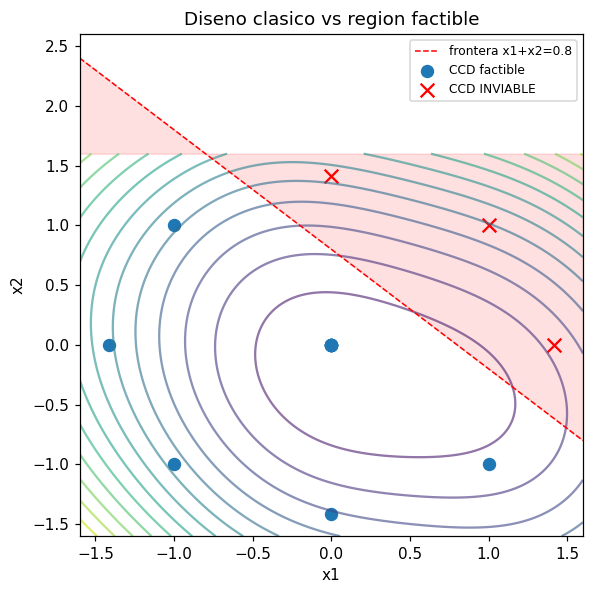

Puntos del CCD que violan la restriccion: 3 de 16


In [2]:
cc = ed.central_composite(2, alpha="rotatable")
Xcc = cc.matrix.to_numpy()
viola = ~factible(Xcc[:,0], Xcc[:,1])

fig, ax = plt.subplots(figsize=(5.5,5.5))
gx = np.linspace(-1.6,1.6,200)
XX,YY = np.meshgrid(gx,gx)
ax.contour(XX,YY,caja_negra(XX,YY), levels=15, cmap="viridis", alpha=0.6)
ax.fill_between([-1.6,1.6],[0.8-(-1.6),0.8-1.6],[1.6,1.6], color="red", alpha=0.12)
ax.plot([-1.6,1.6],[0.8+1.6,0.8-1.6],"r--",lw=1, label="frontera x1+x2=0.8")
ax.scatter(Xcc[~viola,0],Xcc[~viola,1],c="tab:blue",s=60,label="CCD factible")
ax.scatter(Xcc[viola,0],Xcc[viola,1],c="red",marker="x",s=80,label="CCD INVIABLE")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title("Diseno clasico vs region factible")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Puntos del CCD que violan la restriccion:", int(viola.sum()), "de", len(Xcc))


## 2. Diseño D-óptimo sobre el candidate set factible

Generamos un conjunto denso de candidatos, lo filtramos por la restricción y
pedimos a `optimal_design` el subconjunto D-óptimo para un modelo cuadrático.
El presupuesto es fijo: 10 corridas.


In [3]:
N_RUNS = 10
grid = np.array(np.meshgrid(np.linspace(-1,1,21), np.linspace(-1,1,21))).reshape(2,-1).T
grid = grid[factible(grid[:,0], grid[:,1])]
cand = ed.Design(matrix=pd.DataFrame(grid, columns=["x1","x2"]),
                 model=ed.Model.full_quadratic(["x1","x2"]))
dopt = ed.optimal_design(cand, n_runs=N_RUNS, criterion="D", n_starts=8, seed=3)
print("Diseno D-optimo:", dopt.n_runs, "corridas")
print("Criterios:", dopt.metadata["criteria"])


Diseno D-optimo: 10 corridas
Criterios: {'D': 0.35694, 'A': 0.20072, 'T': 0.634315, 'G': 8.000439, 'E': 0.063641, 'I': 2.239412}


In [4]:
# Evaluar el diseno D-optimo vs un diseno aleatorio factible del mismo tamano
rng = np.random.default_rng(0)
ridx = rng.choice(len(grid), N_RUNS, replace=False)
rand_d = ed.Design(matrix=pd.DataFrame(grid[ridx], columns=["x1","x2"]),
                   model=ed.Model.full_quadratic(["x1","x2"]))

for nombre, d in [("D-optimo", dopt), ("Aleatorio", rand_d)]:
    e = ed.efficiencies(d, seed=0)
    print("%-10s  D-eff=%5.1f%%  G-eff=%5.1f%%  SPV medio=%.2f" %
          (nombre, e["D_efficiency"], e["G_efficiency"], e["spv_mean"]))


D-optimo    D-eff= 35.7%  G-eff= 13.3%  SPV medio=5.73
Aleatorio   D-eff= 14.4%  G-eff=  3.5%  SPV medio=16.34


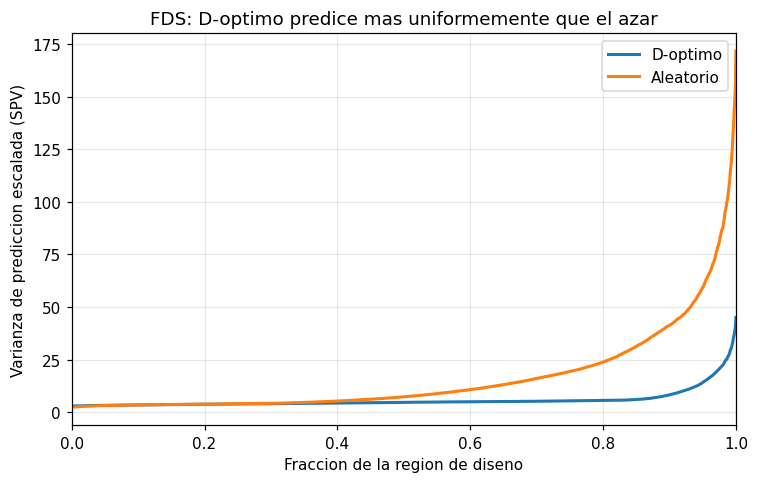

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
plotting.fds_plot(dopt, ax=ax, label="D-optimo", seed=0)
plotting.fds_plot(rand_d, ax=ax, label="Aleatorio", seed=0)
ax.set_title("FDS: D-optimo predice mas uniformemente que el azar")
plt.tight_layout(); plt.show()


## 3. Benchmark: calidad del surrogate y recuperación del óptimo

Cada diseño se usa como conjunto de entrenamiento de un modelo cuadrático
(surrogate). Medimos (a) el RMSE del surrogate sobre una malla de test factible y
(b) el error del óptimo recuperado, y comparamos el D-óptimo contra 300 diseños
aleatorios del mismo presupuesto.


In [6]:
m = ed.Model.full_quadratic(["x1","x2"])
test = grid.copy()
y_test = caja_negra(test[:,0], test[:,1])
x_opt_true = test[np.argmin(y_test)]

def surrogate_metrics(design_points, seed):
    df = pd.DataFrame(design_points, columns=["x1","x2"])
    y = caja_negra(df["x1"].to_numpy(), df["x2"].to_numpy(), ruido=0.05, seed=seed)
    beta,_,_,_ = np.linalg.lstsq(m.matrix(df), y, rcond=None)
    yhat = m.matrix(pd.DataFrame(test, columns=["x1","x2"])) @ beta
    rmse = np.sqrt(np.mean((yhat - y_test)**2))
    x_hat = test[np.argmin(yhat)]
    return rmse, np.linalg.norm(x_hat - x_opt_true)

rmse_dopt, err_dopt = surrogate_metrics(dopt.matrix.to_numpy(), seed=11)
rr = [surrogate_metrics(grid[rng.choice(len(grid), N_RUNS, replace=False)], seed=s)
      for s in range(300)]
rmse_rng = np.array([a for a,_ in rr]); err_rng = np.array([b for _,b in rr])

print("RMSE del surrogate (menor es mejor):")
print("  D-optimo:            %.4f" % rmse_dopt)
print("  Aleatorio (mediana): %.4f  (peor 10%%: %.4f)" % (np.median(rmse_rng), np.percentile(rmse_rng,90)))
print("\nError al optimo:")
print("  D-optimo:            %.4f" % err_dopt)
print("  Aleatorio (mediana): %.4f" % np.median(err_rng))


RMSE del surrogate (menor es mejor):
  D-optimo:            0.0917
  Aleatorio (mediana): 0.1309  (peor 10%: 0.2651)

Error al optimo:
  D-optimo:            0.2000
  Aleatorio (mediana): 0.2236


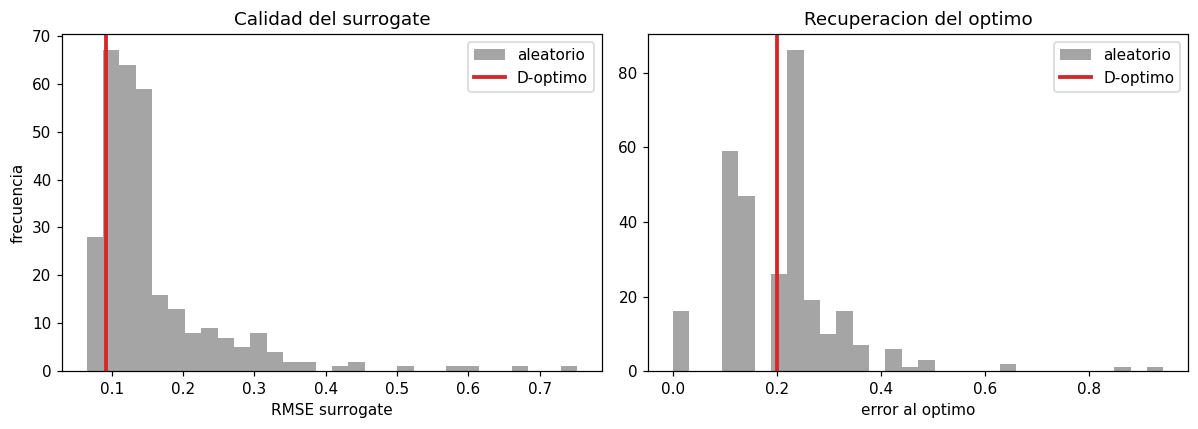

In [7]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
a1.hist(rmse_rng,bins=30,color="tab:gray",alpha=0.7,label="aleatorio")
a1.axvline(rmse_dopt,color="tab:red",lw=2.5,label="D-optimo")
a1.set_xlabel("RMSE surrogate"); a1.set_ylabel("frecuencia"); a1.set_title("Calidad del surrogate"); a1.legend()
a2.hist(err_rng,bins=30,color="tab:gray",alpha=0.7,label="aleatorio")
a2.axvline(err_dopt,color="tab:red",lw=2.5,label="D-optimo")
a2.set_xlabel("error al optimo"); a2.set_title("Recuperacion del optimo"); a2.legend()
plt.tight_layout(); plt.show()


## 4. Veredicto

- La restricción hacía **inviables** varios puntos del diseño clásico; el **diseño
  D-óptimo** respeta la región factible por construcción.
- Con el mismo presupuesto de corridas, el D-óptimo produce un surrogate **más
  preciso y más estable** (menor RMSE y menor varianza) que el muestreo aleatorio,
  y recupera mejor el óptimo.
- El boletín de `doekit` (`efficiencies`, `fds_plot`) cuantifica esa ventaja *antes*
  de gastar evaluaciones caras.

**Cuándo NO usar esto:** si la respuesta es muy multimodal o de alta frecuencia, un
modelo cuadrático es insuficiente y conviene optimización bayesiana. El DoE brilla
cuando la respuesta es suave y cada evaluación es cara.


## Reporte del experimento (guía semántica)

El cierre de todo DoE es el **reporte**: qué se hizo, qué tan bueno fue el diseño, qué observar y qué concluir. Generamos el HTML autocontenido y mostramos su **guía semántica inline** para validar que coincide con lo que el análisis de arriba mostró.

In [8]:
y_dopt = caja_negra(dopt.matrix["x1"].to_numpy(), dopt.matrix["x2"].to_numpy(), ruido=0.05, seed=11)
rep = ed.report(dopt, response=y_dopt, output_dir="reports",
                filename="reporte_05_optimizacion.html", title="Diseno optimo (surrogate)")
guide = ed.report_summary(dopt, response=y_dopt)

print("METODOLOGIA\n ", guide["methodology"], "\n")
print("RESUMEN EJECUTIVO")
for b in guide["executive_summary"]:
    print("  -", b)
print("\nRECOMENDACIONES (que accionar / que observar)")
for r in guide["recommendations"]:
    print("  ->", r)
an = guide["anomalies"]
if an is not None and len(an):
    print("\nVALORES ANOMALOS (corridas a revisar):")
    print(an.to_string(index=False))
print("\nReporte HTML autocontenido en:", rep)


METODOLOGIA
  Diseno optimo: subconjunto que maximiza la informacion segun el criterio elegido, util en regiones restringidas. Criterio D via kl. 

RESUMEN EJECUTIVO
  - Calidad del diseno: D-eficiencia 36% (baja), G-eficiencia 13%.
  - Terminos significativos: x1, x2, x1:x2, x1^2, x2^2. R2=0.998 (ajustado 0.995).

RECOMENDACIONES (que accionar / que observar)
  -> La D-eficiencia (36%) esta por debajo del umbral aceptable (70%): aumenta n_starts, anade corridas o mejora el candidate set.
  -> Factores/terminos significativos (p<0.05): x1, x2, x1:x2, x1^2, x2^2.

Reporte HTML autocontenido en: reports\reporte_05_optimizacion.html


## ¿Fue el diseño apropiado? (asesor de doekit)

Cierre: el asesor infiere el escenario de lo ejecutado y recomienda el método más apropiado, comparándolo con lo que hicimos — una recomendación coherente con el experimento. El 'mejor' es un trade-off (corridas vs precisión vs predicción); por eso se muestran las alternativas.

In [9]:
rec = guide["recommendation"]
if rec:
    print("DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO")
    print(" ", rec["note"])
    print()
    print(rec["table"].to_string(index=False))
else:
    print("(sin recomendacion: el diseno no tiene modelo asociado)")


DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO
  El diseno ejecutado (D-optimo) coincide con el recomendado para este caso: buena eleccion.

              metodo  corridas  D_eff  G_eff  SPV_medio  en_presupuesto  soporta_modelo
   Central Composite        16   50.0   64.8       3.22           False            True
Definitive Screening         5    NaN    NaN        NaN            True           False
            D-optimo         9   46.2   84.8       4.04            True            True
